In [1]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm

# Укажите путь к корневой папке, содержащей подпапки inaction, move, work
DATASET_PATH = '/home/shizm/DL_LABs/DL-lab6/data'

# Проверим, что папка существует
assert os.path.isdir(DATASET_PATH), f"Путь {DATASET_PATH} не найден!"
print("Датасет найден. Содержимое корневой папки:\n", os.listdir(DATASET_PATH))

Датасет найден. Содержимое корневой папки:
 ['work', 'move', 'inaction']


In [2]:
def get_sequences(base_path):
    """
    Возвращает словарь {class: [список путей к папкам с кадрами]}.
    Предполагается, что внутри каждого класса лежат подпапки с изображениями.
    """
    classes = ['inaction', 'move', 'work']
    data = {}
    for cls in classes:
        cls_dir = os.path.join(base_path, cls)
        if not os.path.isdir(cls_dir):
            print(f"Папка {cls_dir} не найдена, пропускаем")
            continue
        sequences = []
        # Рекурсивно ищем все подпапки, содержащие хотя бы одно изображение
        for root, dirs, files in os.walk(cls_dir):
            if root == cls_dir:
                continue  # исключаем саму папку класса, если там вдруг лежат файлы
            image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            if image_files:
                sequences.append(root)
        data[cls] = sequences
        print(f"Класс {cls}: найдено {len(sequences)} последовательностей")
    return data

# Получаем структуру
sequences_dict = get_sequences(DATASET_PATH)

Класс inaction: найдено 93 последовательностей
Класс move: найдено 150 последовательностей
Класс work: найдено 342 последовательностей


In [3]:
def gather_stats(data):
    """
    Для каждой последовательности собирает: класс, имя папки, количество кадров, 
    размер первого изображения.
    """
    records = []
    for cls, seq_paths in data.items():
        for seq_path in tqdm(seq_paths, desc=f"Обработка {cls}"):
            # Получаем только файлы изображений
            images = sorted([f for f in os.listdir(seq_path) 
                             if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            num_frames = len(images)
            # Определяем размер по первому кадру
            if num_frames > 0:
                sample_path = os.path.join(seq_path, images[0])
                img = cv2.imread(sample_path)
                if img is not None:
                    h, w = img.shape[:2]
                else:
                    h, w = None, None
            else:
                h, w = None, None
            records.append({
                'class': cls,
                'sequence_name': os.path.basename(seq_path),
                'full_path': seq_path,
                'num_frames': num_frames,
                'height': h,
                'width': w
            })
    return pd.DataFrame(records)

df_stats = gather_stats(sequences_dict)
print(f"\nВсего последовательностей: {len(df_stats)}")
df_stats.head(20)

Обработка inaction:   0%|          | 0/93 [00:00<?, ?it/s]

Обработка move:   0%|          | 0/150 [00:00<?, ?it/s]

Обработка work:   0%|          | 0/342 [00:00<?, ?it/s]


Всего последовательностей: 585


,class,sequence_name,full_path,num_frames,height,width
0,inaction,9,/home/shizm/DL_LABs/DL-lab6/data/inaction/9,8,227,177
1,inaction,2,/home/shizm/DL_LABs/DL-lab6/data/inaction/2,8,239,205
2,inaction,166,/home/shizm/DL_LABs/DL-lab6/data/inaction/166,8,476,229
3,inaction,32,/home/shizm/DL_LABs/DL-lab6/data/inaction/32,8,266,136
4,inaction,131,/home/shizm/DL_LABs/DL-lab6/data/inaction/131,8,110,53
5,inaction,200,/home/shizm/DL_LABs/DL-lab6/data/inaction/200,8,438,206
6,inaction,134,/home/shizm/DL_LABs/DL-lab6/data/inaction/134,8,114,56
7,inaction,13,/home/shizm/DL_LABs/DL-lab6/data/inaction/13,8,235,192
8,inaction,225,/home/shizm/DL_LABs/DL-lab6/data/inaction/225,8,398,180
9,inaction,148,/home/shizm/DL_LABs/DL-lab6/data/inaction/148,8,420,258


In [4]:
print("===== Распределение числа последовательностей по классам =====")
print(df_stats['class'].value_counts())

print("\n===== Статистика количества кадров в последовательностях =====")
df_stats.groupby('class')['num_frames'].describe()

===== Распределение числа последовательностей по классам =====
class
work        342
move        150
inaction     93
Name: count, dtype: int64

===== Статистика количества кадров в последовательностях =====


,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
inaction,93.0,8.0,0.0,8.0,8.0,8.0,8.0,8.0
move,150.0,8.0,0.0,8.0,8.0,8.0,8.0,8.0
work,342.0,8.0,0.0,8.0,8.0,8.0,8.0,8.0


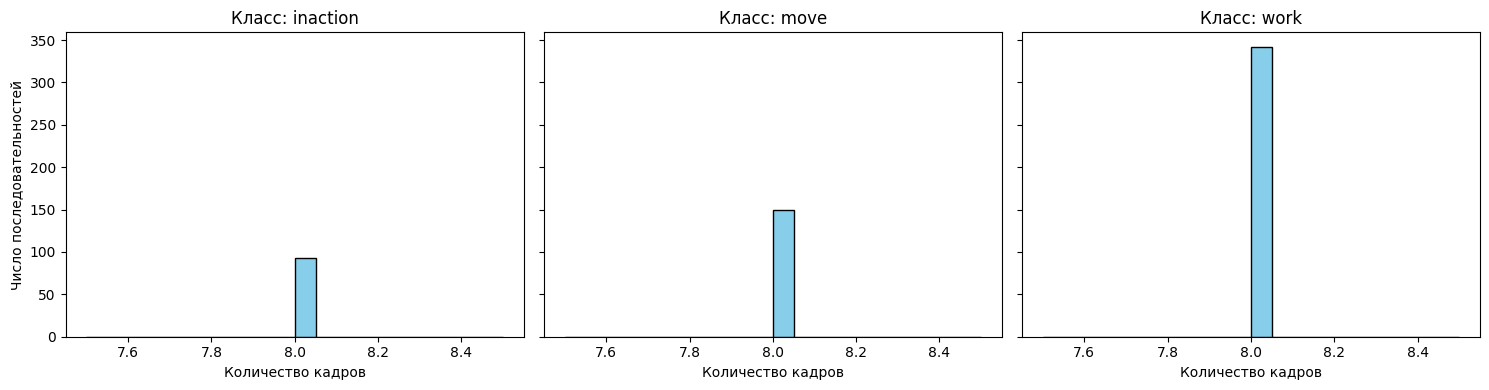

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for i, cls in enumerate(['inaction', 'move', 'work']):
    subset = df_stats[df_stats['class'] == cls]['num_frames']
    axes[i].hist(subset, bins=20, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Класс: {cls}')
    axes[i].set_xlabel('Количество кадров')
    if i == 0:
        axes[i].set_ylabel('Число последовательностей')
plt.tight_layout()
plt.show()

In [6]:
def show_sequence_sample(seq_path, num_display=8):
    """
    Отображает равномерно выбранные кадры из последовательности.
    Если кадров меньше num_display, показывает все.
    """
    images = sorted([f for f in os.listdir(seq_path) 
                     if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    n = len(images)
    if n == 0:
        print("В папке нет изображений")
        return
    
    # Выбираем индексы с равномерным шагом
    idxs = np.linspace(0, n-1, min(num_display, n), dtype=int)
    
    fig, axes = plt.subplots(1, len(idxs), figsize=(15, 3))
    if len(idxs) == 1:
        axes = [axes]
    for ax, idx in zip(axes, idxs):
        img_path = os.path.join(seq_path, images[idx])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f'Кадр {idx+1}')
    plt.show()

Класс: inaction | Папка: track_001449 | Кадров: 8


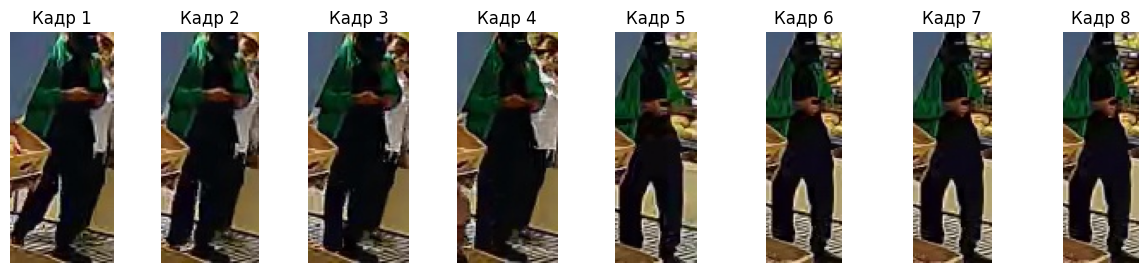


--------------------------------------------------

Класс: move | Папка: track_000275 | Кадров: 8


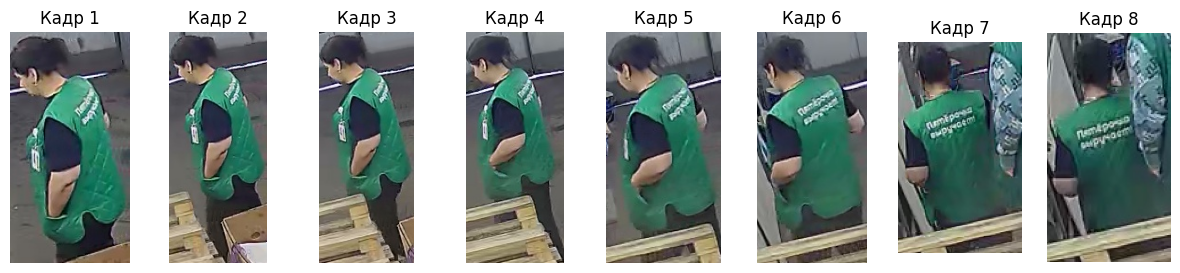


--------------------------------------------------

Класс: work | Папка: 19_1 | Кадров: 8


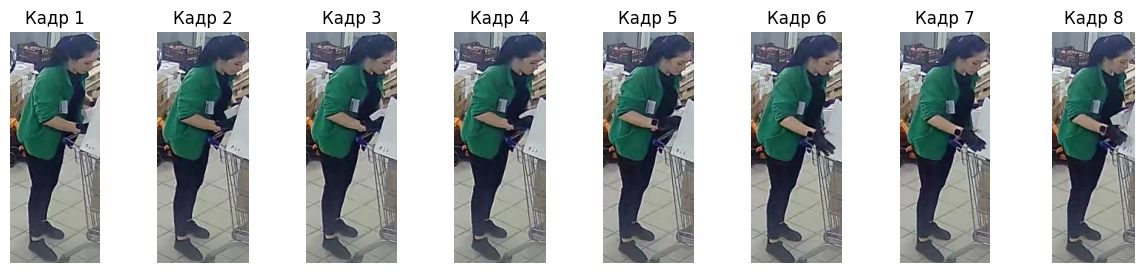


--------------------------------------------------



In [7]:
np.random.seed(42)  # для воспроизводимости

for cls in ['inaction', 'move', 'work']:
    seq_list = sequences_dict[cls]
    if not seq_list:
        print(f"Нет данных для класса {cls}")
        continue
    
    sample_seq = random.choice(seq_list)
    num_frames = len([f for f in os.listdir(sample_seq) 
                      if f.lower().endswith(('.png','.jpg','.jpeg'))])
    print(f"Класс: {cls} | Папка: {os.path.basename(sample_seq)} | Кадров: {num_frames}")
    show_sequence_sample(sample_seq)
    print("\n" + "-"*50 + "\n")

In [8]:
print("Статистика размеров изображений (в пикселях):")
df_stats[['height', 'width']].describe().round(1)

Статистика размеров изображений (в пикселях):


,height,width
count,585.0,585.0
mean,255.0,154.6
std,105.6,80.1
min,44.0,29.0
25%,169.0,86.0
50%,256.0,150.0
75%,322.0,197.0
max,505.0,413.0


In [9]:
# Проверим, все ли изображения имеют одинаковые размеры
unique_dims = df_stats.dropna(subset=['height', 'width']).groupby(['height', 'width']).size().reset_index(name='count')
print("\nУникальные комбинации (высота, ширина) и их количество:")
unique_dims.sort_values('count', ascending=False)


Уникальные комбинации (высота, ширина) и их количество:


,height,width,count
363,289,154,2
553,446,239,2
81,128,47,2
22,94,63,2
16,87,40,2
...,...,...,...
196,203,171,1
197,203,173,1
198,205,102,1
199,205,106,1
